In [ ]:
"""
This script contains checking of miscellaneous data preprocessing functions for the dataset. 
"""

In [1]:
import sys, os
PROJECT_ROOT = "/hpc/dctrl/ks723/Data_augmentation"
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)


In [ ]:

"""
Test script to verify what the dataloader is actually loading
"""

from Data_augmentation.utils.shared_resources_config import CONTROL_SD15_CKPT, CLDM_V15_YAML
from torch.utils.data import DataLoader
from reptorep_dataset import MyDataset

print("\n" + "="*60)
print("TESTING DATALOADER")
print("="*60)

# Create dataset
dataset = MyDataset()

print(f"\nDataset length: {len(dataset)}")

# Create dataloader
dataloader = DataLoader(dataset, batch_size=2, shuffle=False, num_workers=0)

print("\n" + "="*60)
print("LOADING FIRST BATCH (2 samples)")
print("="*60)

# Load first batch
batch = next(iter(dataloader))

print("\n" + "="*60)
print("BATCH CONTENTS:")
print("="*60)
print(f"Keys: {batch.keys()}")
print(f"jpg (target) shape: {batch['jpg'].shape}")
print(f"hint (source) shape: {batch['hint'].shape}")
print(f"txt (prompt): {batch['txt']}")

print("\n" + "="*60)
print("TEST COMPLETE")
print("="*60)






TESTING DATALOADER

=== DATASET INITIALIZATION ===
JSON file: /hpc/group/youlab/ks723/storage/prompt_experiments_augmentation.json
Image folder: /hpc/group/youlab/ks723/storage/Exp_images/Final_folder_uniform_fixedseed_100AUG
Total pairs loaded: 25700
First 3 entries:
  [0] {'source': '1_1_rot0.0.TIF', 'target': '1_2_rot0.0.TIF', 'prompt': ''}
  [1] {'source': '1_1_rot3.5999999999999996.TIF', 'target': '1_2_rot3.5999999999999996.TIF', 'prompt': ''}
  [2] {'source': '1_1_rot7.199999999999999.TIF', 'target': '1_2_rot7.199999999999999.TIF', 'prompt': ''}

Dataset length: 25700

LOADING FIRST BATCH (2 samples)

[LOADING idx=0]
  Source: 1_1_rot0.0.TIF
  Target: 1_2_rot0.0.TIF
  Source path: /hpc/group/youlab/ks723/storage/Exp_images/Final_folder_uniform_fixedseed_100AUG/1_1_rot0.0.TIF
  Target path: /hpc/group/youlab/ks723/storage/Exp_images/Final_folder_uniform_fixedseed_100AUG/1_2_rot0.0.TIF
  Source exists: True
  Target exists: True
  Source shape after preprocessing: (256, 256, 3)
  

File: Fixed_6_1_rot284.4.TIF, Shape: (1001, 1001, 3)


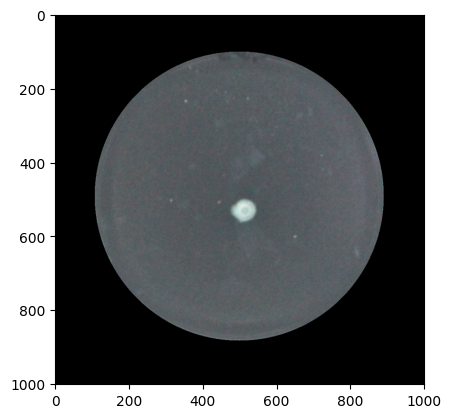

File: 100_1_rot0.0.TIF, Shape: (1001, 1001, 3)


In [5]:
# see file image sizes
from local_config import EXP_IMAGES_FOLDER, MUTANT_EXP_FOLDER_AUG
dir1_path= EXP_IMAGES_FOLDER
dir2_path= MUTANT_EXP_FOLDER_AUG
import matplotlib.pyplot as plt

import os 
import cv2

for file in os.listdir(dir1_path):
    if file.endswith('.TIF'):
        img_path= os.path.join(dir1_path, file)
        img= cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
        print(f"File: {file}, Shape: {img.shape}")
        break # only see 1 file

for file in sorted(os.listdir(dir2_path)):
    if file.endswith('.TIF'):
        img_path= os.path.join(dir2_path, file)
        img= cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
        # convert bgr to rgb
        img= cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.imshow(img, cmap='gray')
        plt.show()
        print(f"File: {file}, Shape: {img.shape}")
        break # only see 1 file

File: Fixed_6_1_rot284.4.TIF, Shape: (1001, 1001, 3)


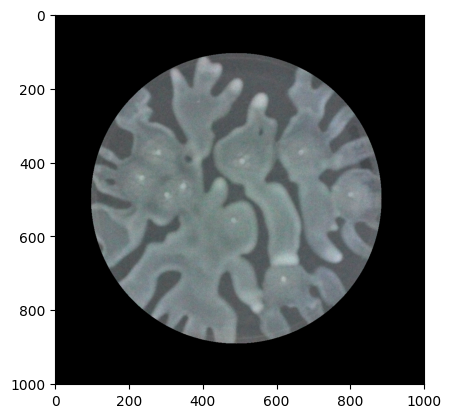

File: 1000_1.TIF, Shape: (1001, 1001, 3)


In [1]:
# see file image sizes
from local_config import EXP_IMAGES_FOLDER, EXP_FOLDER_KS_NOAUG
dir1_path= EXP_IMAGES_FOLDER
dir2_path= EXP_FOLDER_KS_NOAUG
import matplotlib.pyplot as plt

import os 
import cv2


for file in os.listdir(dir1_path):
    if file.endswith('.TIF'):
        img_path= os.path.join(dir1_path, file)
        img= cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
        print(f"File: {file}, Shape: {img.shape}")
        break # only see 1 file

for file in sorted(os.listdir(dir2_path)):
    if file.endswith('.TIF'):
        img_path= os.path.join(dir2_path, file)
        img= cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
        # convert bgr to rgb
        img= cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.imshow(img, cmap='gray')
        plt.show()
        print(f"File: {file}, Shape: {img.shape}")
        break # only see 1 file

In [2]:
# testing the limits of combinations without data augmentation. 
# since the downstream pipeline deals with processed images, create a new folder with processed images without augmentation



In [4]:
# Adding Kristen's 2 species dataset to the mix

# The images currently include the boundary colonies, which we now know are extra bright
# will have to manually exclude those images 

# The files are labelled as x-y_z.TIF
# x is the GFP strain fraction
# y is the mCherry strain fraction
# z is the replicate number 

# First find how many unique combinations of x and y are there, and just list them in increasing order of relative fraction of GFP to mCherry.
import os
from utils.local_config import KRISTEN_EXP_FOLDER_2SP
import re
import numpy as np
from natsort import natsorted

files = natsorted(os.listdir(KRISTEN_EXP_FOLDER_2SP))
# Use a set to store unique combinations of x and y
unique_combinations = set()

for file in files:
    if file.endswith('.jpg'):
        # Extract x and y using regex
        match = re.match(r'(\d+)-(\d+)_\d+\.jpg', file)
        if match:
            x, y = match.groups()
            unique_combinations.add((int(x), int(y)))

# Convert the set to a sorted list
unique_combinations = sorted(unique_combinations)
print(unique_combinations)


# check that all the combinations add upto 100% which is 348 images so whatever combinations times 12 replicates
expected_images = len(unique_combinations) * 12
print(f"Expected number of images: {expected_images}")

actual_images = len(files)
print(f"Actual number of images: {actual_images}")
if actual_images != expected_images:
    print("Warning: The actual number of images does not match the expected number of images.")

[(0, 1), (1, 0), (1, 1), (1, 3), (1, 4), (1, 5), (1, 7), (1, 9), (1, 19), (1, 49), (2, 3), (3, 1), (3, 2), (3, 5), (3, 7), (4, 1), (4, 5), (5, 1), (5, 3), (5, 4), (7, 1), (7, 3), (7, 8), (7, 13), (8, 7), (9, 1), (13, 7), (19, 1), (49, 1)]
Expected number of images: 348
Actual number of images: 348


In [5]:
# arrange the images in increasing order of fraction of GFP to mCherry


# Algo: x/(x+y) gives fraction of GFP, y/(x+y) gives fraction of mCherry

# Sort the unique combinations based on the fraction of GFP
unique_combinations_sorted = sorted(unique_combinations, key=lambda comb: comb[0] / (comb[0] + comb[1]))
print(unique_combinations_sorted)


[(0, 1), (1, 49), (1, 19), (1, 9), (1, 7), (1, 5), (1, 4), (1, 3), (3, 7), (7, 13), (3, 5), (2, 3), (4, 5), (7, 8), (1, 1), (8, 7), (5, 4), (3, 2), (5, 3), (13, 7), (7, 3), (3, 1), (4, 1), (5, 1), (7, 1), (9, 1), (19, 1), (49, 1), (1, 0)]


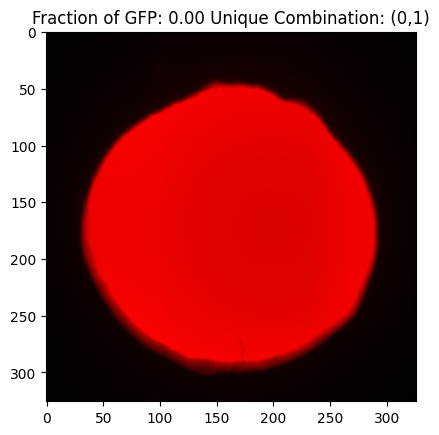

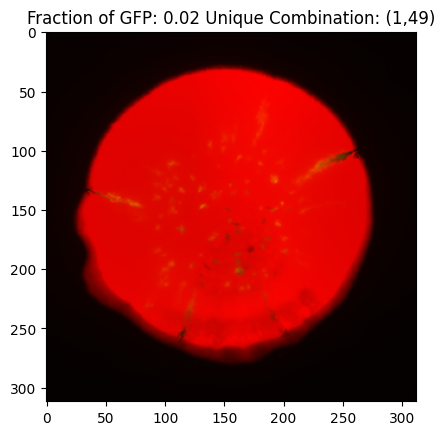

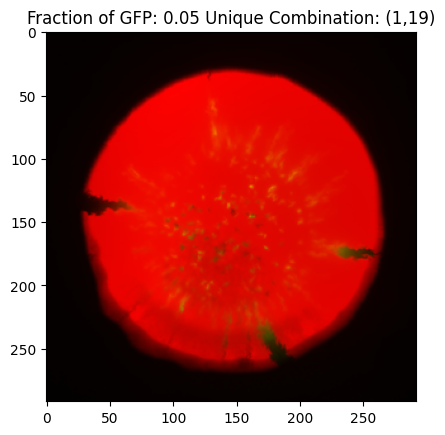

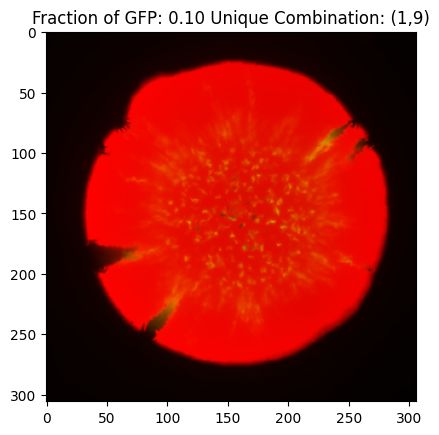

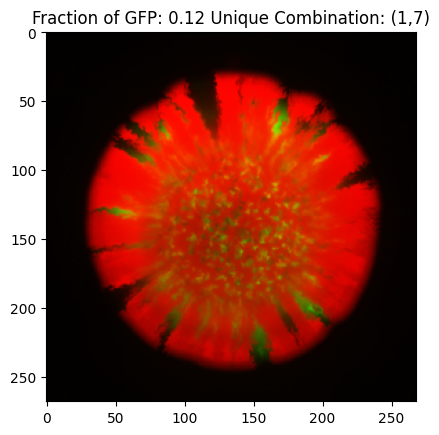

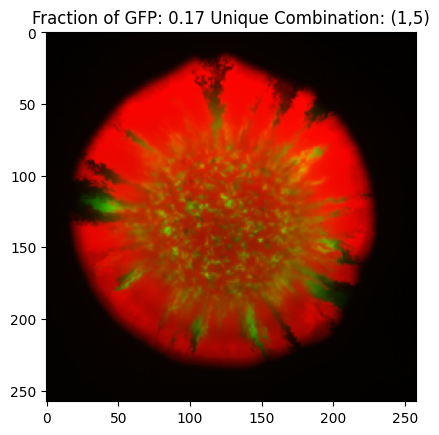

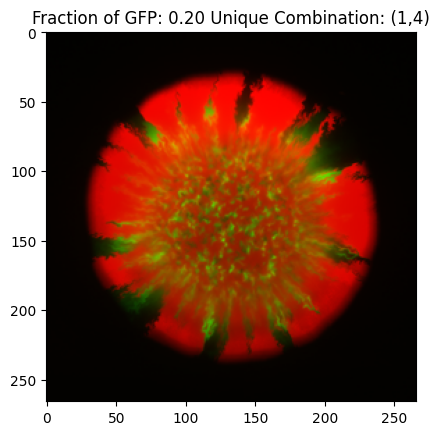

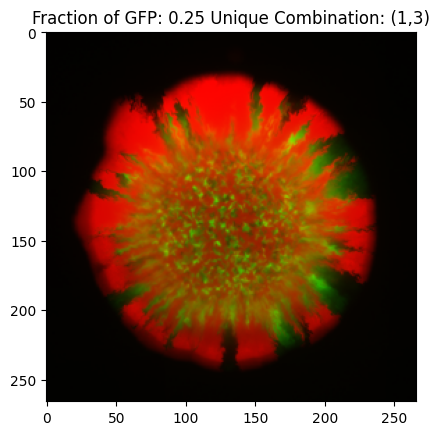

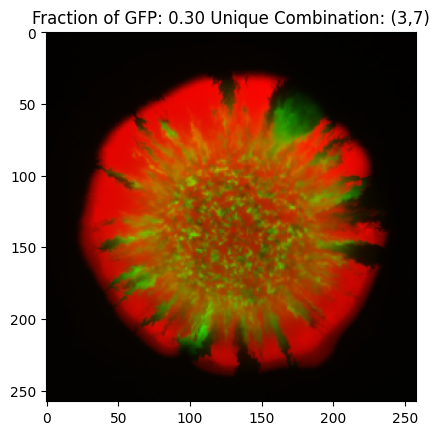

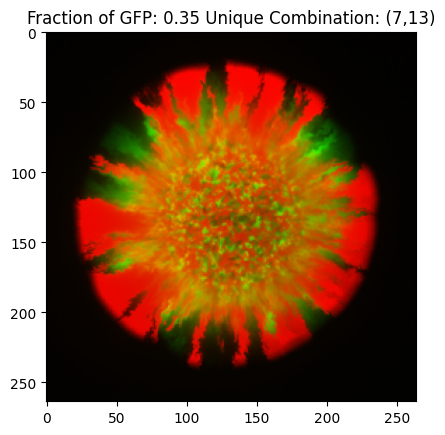

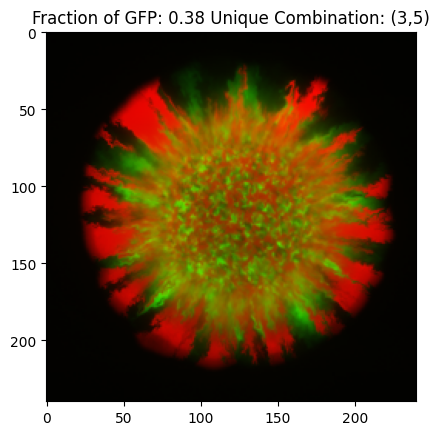

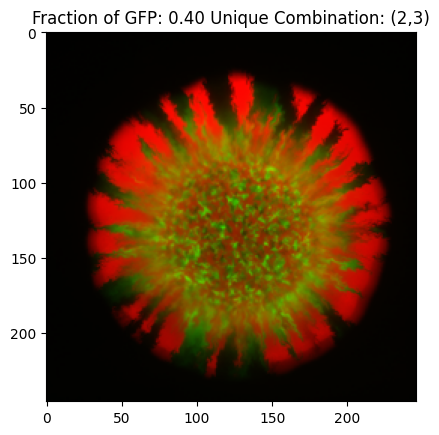

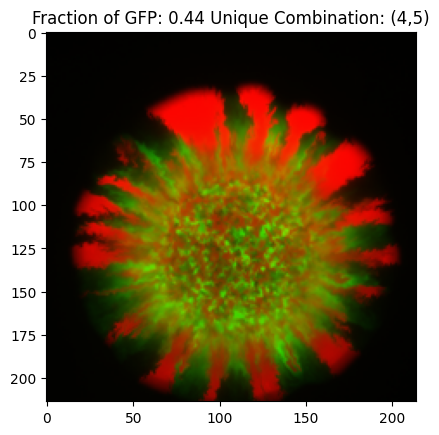

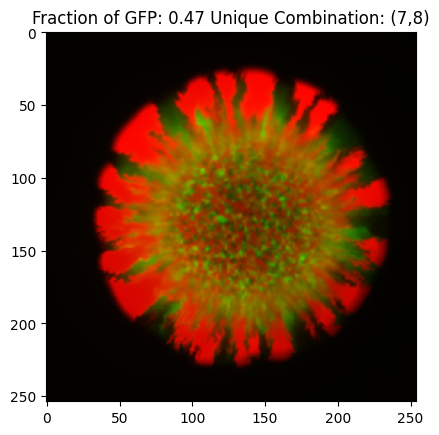

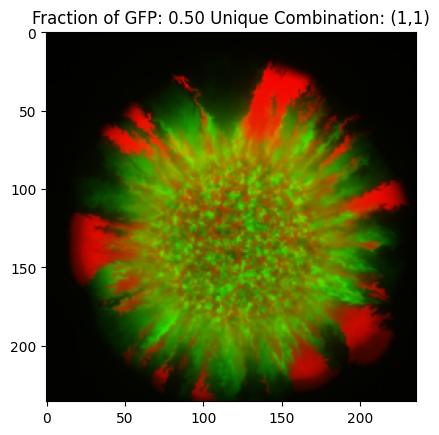

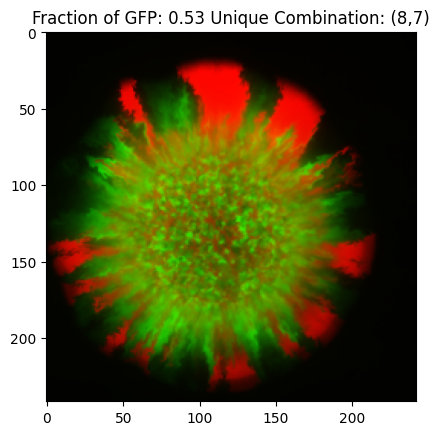

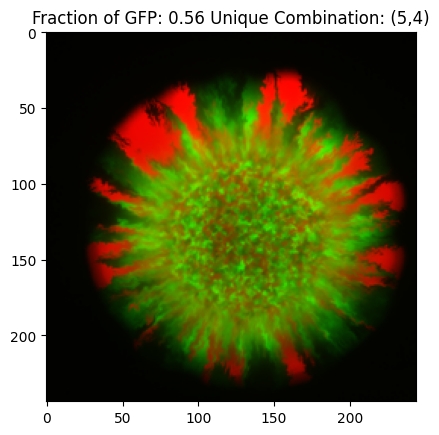

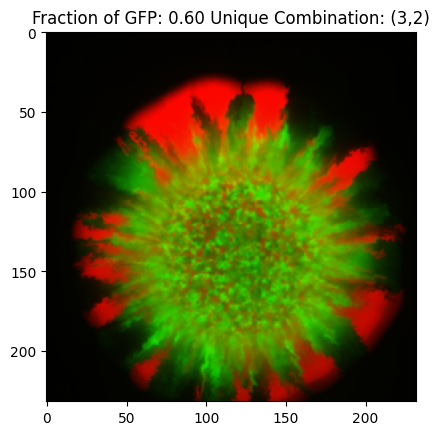

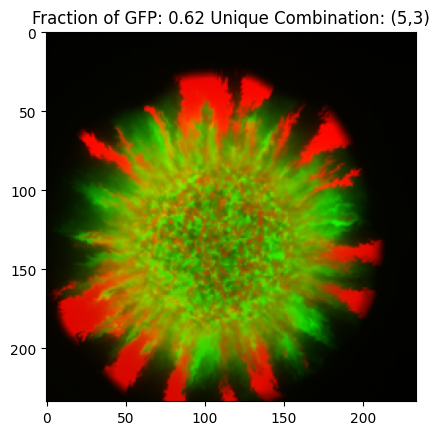

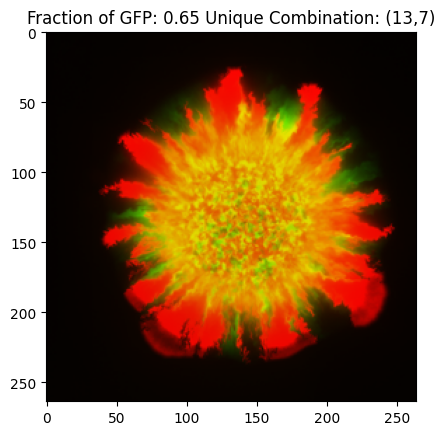

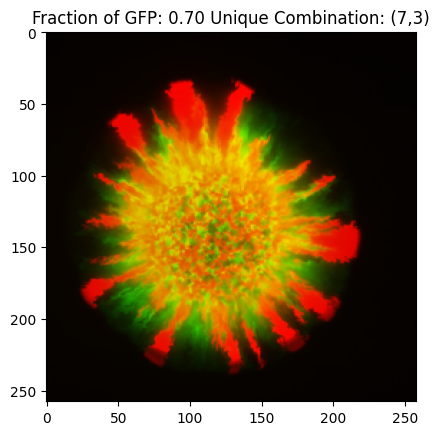

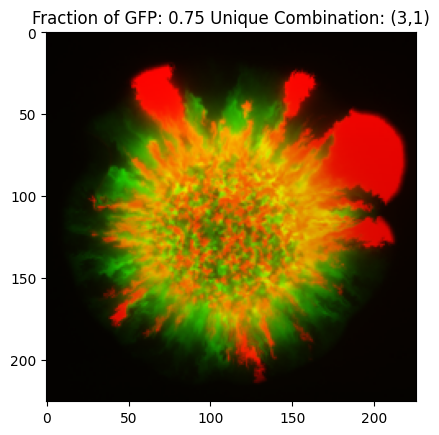

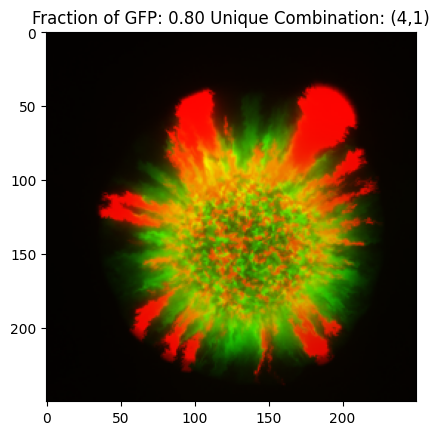

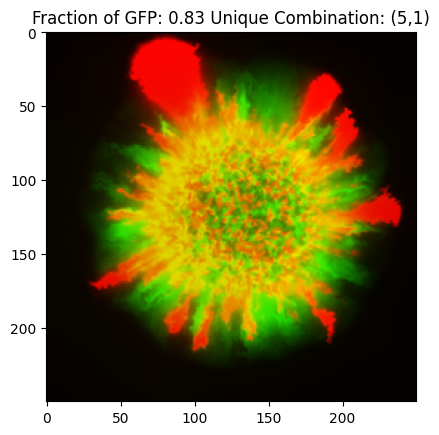

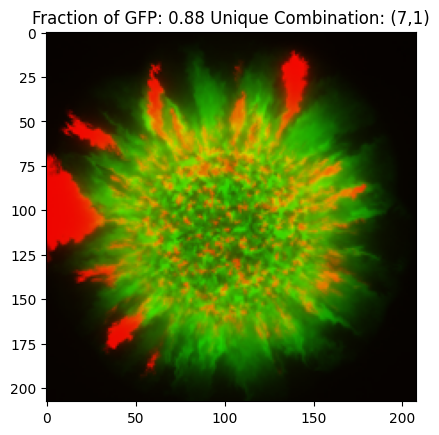

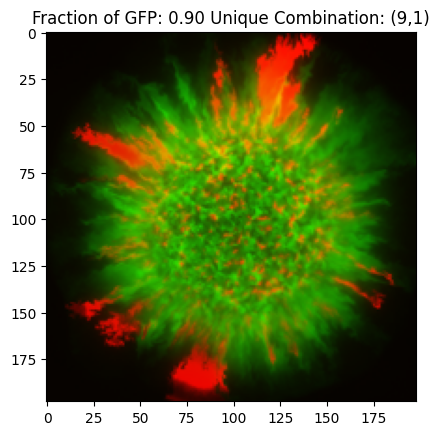

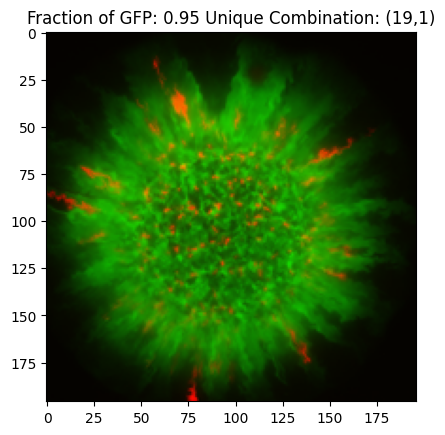

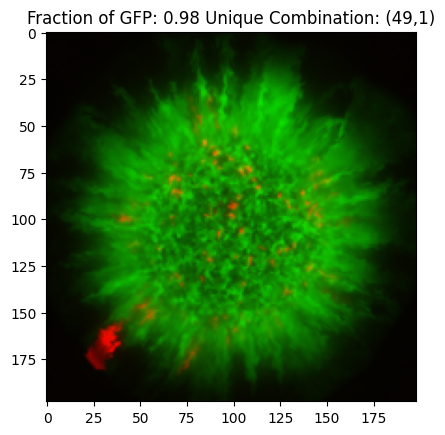

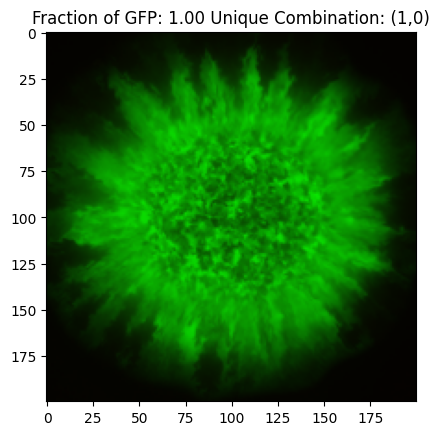

In [11]:
# show the images with the first replicate of the unique combinations sorted

import matplotlib.pyplot as plt

for x, y in unique_combinations_sorted:
    # Construct the filename for the first replicate
    filename = f"{x}-{y}_1.jpg"
    file_path = os.path.join(KRISTEN_EXP_FOLDER_2SP, filename)
    if filename in files:
        img = plt.imread(file_path)
        plt.imshow(img)
        plt.title(f"Fraction of GFP: {x/(x+y):.2f} Unique Combination: ({x},{y})")

        plt.show()

In [8]:
# count the total number of fractions

print(f"The total number of fractions is: {len(unique_combinations_sorted)}")

The total number of fractions is: 29


In [ ]:
# Filter out some replicates in a different folder
# These replicates are the ones that are at the edges of the colonies

# Fraction (1,0)
# Discard reps 1-6, 7 and 12 (edge cases that are too bright)  # Category A

# Fraction (49,1)
# Discard reps 1, 6, 7 and 12       # Category B

# Fraction (19,1)
# Discard reps 1, 6, 7 and 12  # Category B

# Fraction (9,1)
# Discard reps 1, 6, 7 and 12  # Category B

# Fraction (7,1)
# Discard reps 1,6 and 7-12    # Category C


# same patterns for other plates 

# Category A (1,0) | (5,1) | (5,3) | (7,8) | (7,13) | (1,9)
# Category B (49,1) (19,1) (9,1) | (4,1) (3,1) (7,3) | (3,2) (5,4) (8,7) | (4,5) (2,3) (3,5) | (1,5) (1,4) (1,3) | (1,19) (1,49)
# Category C (7,1) | (13,7) | (1,1) | (3,7) | (1,7) | (0,1)


# I think (3,7) and (7,13) are interchanged from raw images for some reason ? Check with Kristen later 

from utils.local_config import KRISTEN_EXP_FOLDER_2SP, KRISTEN_EXP_FOLDER_2SP_FILTERED

if os.path.exists(KRISTEN_EXP_FOLDER_2SP_FILTERED) == False:
    os.makedirs(KRISTEN_EXP_FOLDER_2SP_FILTERED)

import numpy as np
import shutil


# Move desired files based on the above categories 

# Category A left edge 
pattern_A=["1-0", "5-1", "5-3", "7-8", "7-13", "1-9"]
desired_files_A= np.array([8,9,10,11])

# Category B center 
pattern_B= ["49-1", "19-1", "9-1", "4-1", "3-1", "7-3", "3-2", "5-4", "8-7", "4-5", "2-3", "3-5", "1-5", "1-4", "1-3", "1-19", "1-49"]
desired_files_B= np.array([2,3,4,5,8,9,10,11])

# Category C right edge
pattern_C= ["7-1", "13-7", "1-1", "3-7", "1-7", "0-1"]
desired_files_C= np.array([2,3,4,5])

# copy files to desired folder 

for pattern in pattern_A:
    for file_idx in desired_files_A:
        src_file = f"{KRISTEN_EXP_FOLDER_2SP}/{pattern}_{file_idx}.jpg"
        dst_file = f"{KRISTEN_EXP_FOLDER_2SP_FILTERED}/{pattern}_{file_idx}.jpg"
        shutil.copy(src_file, dst_file)

for pattern in pattern_B:
    for file_idx in desired_files_B:
        src_file = f"{KRISTEN_EXP_FOLDER_2SP}/{pattern}_{file_idx}.jpg"
        dst_file = f"{KRISTEN_EXP_FOLDER_2SP_FILTERED}/{pattern}_{file_idx}.jpg"
        shutil.copy(src_file, dst_file)

for pattern in pattern_C:
    for file_idx in desired_files_C:
        src_file = f"{KRISTEN_EXP_FOLDER_2SP}/{pattern}_{file_idx}.jpg"
        dst_file = f"{KRISTEN_EXP_FOLDER_2SP_FILTERED}/{pattern}_{file_idx}.jpg"
        shutil.copy(src_file, dst_file)



In [5]:

# perform rough check 

total_count_tobe= len(pattern_A) * len(desired_files_A) + len(pattern_B) * len(desired_files_B) + len(pattern_C) * len(desired_files_C)
total_count_actual= len(os.listdir(KRISTEN_EXP_FOLDER_2SP_FILTERED))
print(f"Total count to be copied: {total_count_tobe}")
print(f"Total count actually copied: {total_count_actual}")

Total count to be copied: 184
Total count actually copied: 184


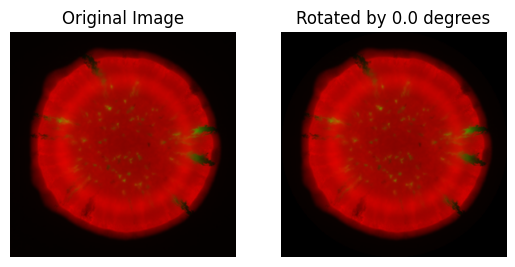

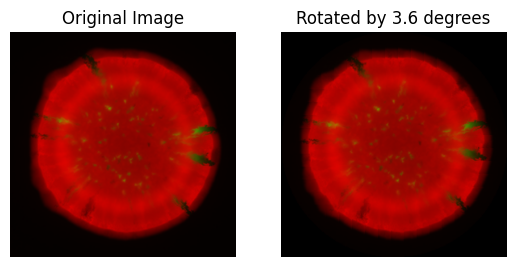

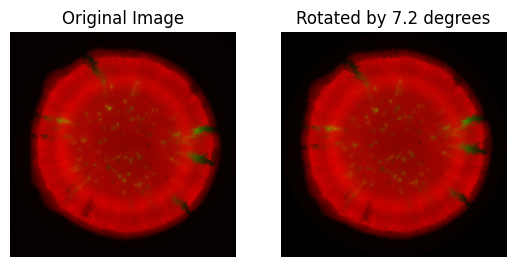

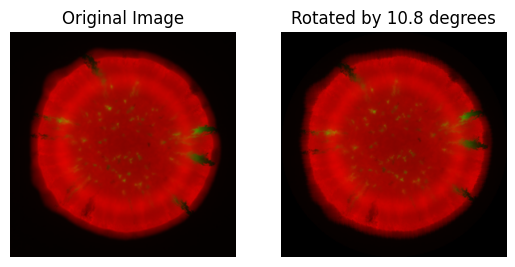

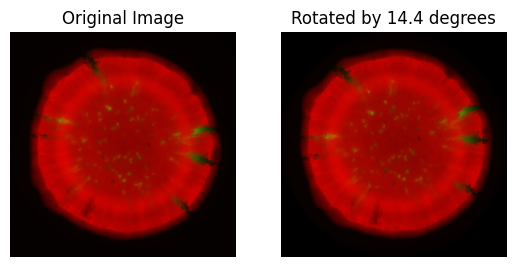

Done. Augmented images written to: /hpc/group/youlab/ks723/storage/Exp_images/KL_automatedcrops_2species_filtered_renamed_AUG100


In [9]:
# Testing the augmentation script from multiplexed_patterning project 

"""Basic rotation augmentation for circular colony images.

This script creates 100 rotated copies per image (default) using OpenCV.
No Hough transform, cropping, or brightness/contrast adjustment is applied.
"""

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from utils.local_config import KRISTEN_EXP_FOLDER_2SP_FILTERED_RENAMED


def rotate_with_inscribed_circle_mask(img: np.ndarray, angle: float) -> np.ndarray:
	"""Rotate image around center and keep only the inscribed circular region."""
	h, w = img.shape[:2]
	cx, cy = w // 2, h // 2
	radius = min(cx, cy)

	rotation_matrix = cv2.getRotationMatrix2D((cx, cy), angle, 1.0)
	rotated = cv2.warpAffine(img, rotation_matrix, (w, h), flags=cv2.INTER_NEAREST)

	mask = np.zeros((h, w), dtype=np.uint8)
	cv2.circle(mask, (cx, cy), radius, 255, -1)
	return cv2.bitwise_and(rotated, rotated, mask=mask)


def augment_folder_by_rotation(
	input_folder: str,
	output_folder: str,
	n_rotations: int = 100,
	valid_exts=(".jpg", ".tiff"),
) -> None:
	os.makedirs(output_folder, exist_ok=True)

	files = sorted(
		f for f in os.listdir(input_folder)
		if os.path.isfile(os.path.join(input_folder, f))
		and f.lower().endswith(valid_exts)
	)

	angles = np.linspace(0, 360, n_rotations, endpoint=False)

	count=0
	for i, filename in enumerate(files, start=1):
		src_path = os.path.join(input_folder, filename)
		img = cv2.imread(src_path, cv2.IMREAD_COLOR)
		if img is None:
			print(f"[WARN] Skipping unreadable file: {filename}")
			continue

		stem, ext = os.path.splitext(filename)
		for angle in angles:
			rotated = rotate_with_inscribed_circle_mask(img, float(angle))

			# Display the rotated image using matplotlib and Display the base image for comparision on the side
			plt.subplot(1, 2, 1)
			plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
			plt.title("Original Image")
			plt.axis("off")

			plt.subplot(1, 2, 2)
			plt.imshow(cv2.cvtColor(rotated, cv2.COLOR_BGR2RGB))
			plt.title(f"Rotated by {angle:.1f} degrees")
			plt.axis("off")
			plt.show()
			count+=1
			if count>=5:
				break
            
			# out_name = f"{stem}_rot{angle:.1f}{ext}"
			# out_path = os.path.join(output_folder, out_name)
			# cv2.imwrite(out_path, rotated)
    
		if i % 25 == 0 or i == len(files):
			print(f"Processed {i}/{len(files)} images")
		break
		
		

	print(f"Done. Augmented images written to: {output_folder}")


if __name__ == "__main__":
	input_folder = KRISTEN_EXP_FOLDER_2SP_FILTERED_RENAMED
	output_folder = f"{input_folder.rstrip('/')}_AUG100"
	augment_folder_by_rotation(input_folder=input_folder, output_folder=output_folder, n_rotations=100)

